## 0. Environment

In [38]:
# ==============================
# Initialization: Environment & Backends
# ==============================

# If needed:
# %pip install -q accelerate>=0.34.2 safetensors>=0.4.3 sentencepiece packaging

import os, re, json, random
import numpy as np
import torch
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, Any
from sklearn.metrics import accuracy_score, f1_score

# ---- Repro ----
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ---- Device & backend ----
device  = "cuda" if torch.cuda.is_available() else "cpu"
BACKEND = os.environ.get("LLM_BACKEND", "hf")  # "hf" or "openai"

# ---- Models ----
HF_MODEL   = os.environ.get("HF_MODEL", "TinyLlama/TinyLlama-1.1B-Chat-v1.0")
GPT5_MODEL = os.environ.get("GPT5_MODEL", "gpt-5")
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")

print(f"Device: {device}")
print(f"Backend: {BACKEND}")
print(f"HF Model: {HF_MODEL if BACKEND=='hf' else 'N/A'}")
print(f"GPT-5 Model: {GPT5_MODEL if BACKEND=='openai' else 'N/A'}")

# GTX 1080 Ti notes: no bfloat16, SDPA/flash attn can be flaky -> force eager attention
ATTN_IMPL = "eager"  # safe default for older GPUs

if BACKEND == "hf":
    from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer

    # Load config first to pin attention implementation
    config = AutoConfig.from_pretrained(HF_MODEL)
    try:
        # Not every config exposes this, so guard it
        setattr(config, "attn_implementation", ATTN_IMPL)
    except Exception:
        pass

    tokenizer = AutoTokenizer.from_pretrained(HF_MODEL, use_fast=True)
    model = AutoModelForCausalLM.from_pretrained(
        HF_MODEL,
        config=config,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        low_cpu_mem_usage=True,
        trust_remote_code=False,   # flip to True only if your model requires it
    )
    # Pad token safety
    if tokenizer.pad_token is None and tokenizer.eos_token is not None:
        tokenizer.pad_token = tokenizer.eos_token

    # Move to device
    model.to(device)
    model.eval()
    print("✅ Loaded HF model (fp16 on CUDA if available), attention=eager.")
else:
    import openai
    if not OPENAI_API_KEY:
        raise EnvironmentError("OPENAI_API_KEY not set; export it to use the OpenAI backend.")
    openai.api_key = OPENAI_API_KEY
    print(f"✅ OpenAI backend ready (model={GPT5_MODEL})")


Device: cuda
Backend: openai
HF Model: N/A
GPT-5 Model: gpt-5
✅ OpenAI backend ready (model=gpt-5)


## 1. Task Generator

In [39]:
@dataclass
class ClfTask:
    W: np.ndarray
    X: np.ndarray
    y: np.ndarray
    x_test: np.ndarray
    y_test: int

def sample_clf_task(d: int = 10, N: Optional[int] = None, alpha: float = 1.0) -> ClfTask:
    if N is None: N = 2*d + 1
    W = np.random.randn(d)
    X = np.random.uniform(-alpha, alpha, size=(N, d))
    y = np.sign(X @ W).astype(int); y[y==0] = 1
    x_t = np.random.uniform(-alpha, alpha, size=(d,))
    y_t = int(np.sign(x_t @ W) or 1)
    return ClfTask(W, X, y, x_t, y_t)

## 2. GD-1 Baseline

In [40]:
def gd1_clf_predict(X: np.ndarray, y: np.ndarray, x_test: np.ndarray, eta: float = 1.0) -> int:
    N = X.shape[0]
    W1 = (0.5 * eta / N) * (y[:, None] * X).sum(axis=0)
    return 1 if float(W1 @ x_test) >= 0 else -1

## 3. Prompt Construction

In [45]:
FLOAT_RE = re.compile(r"[-+]?(?:\\d*\\.\\d+|\\d+)(?:[eE][-+]?\\d+)?")

def fmtv(x, digits=5): return ", ".join(f"{v:.{digits}f}" for v in x.tolist())

def build_prompt(t: ClfTask, digits: int = 5):
    ctx = "\n".join([f"({fmtv(t.X[i],digits)}) -> {int(t.y[i])}" for i in range(t.X.shape[0])])
    xs  = fmtv(t.x_test,digits)
    return (f"You are solving a noiseless linear classification task: y = sign(W · x).\n"
            f"Given training pairs (x -> y) with y in {{-1, +1}}, predict y for x_test.\n\n"
            f"{ctx}\n\nx_test = [{xs}]\n"
            f"Respond with a single integer: -1 or +1 (no text, no punctuation).")

FLOAT_RE = re.compile(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?")

def parse_label(text: str):
    if text is None:
        return None
    text = str(text).strip()
    if not text:
        return None

    toks = text.split()
    last = toks[-1] if toks else ""

    if last in {"-1", "+1", "1"}:
        return -1 if last == "-1" else +1

    nums = FLOAT_RE.findall(text)
    if nums:
        try:
            v = float(nums[-1])
            return -1 if v < 0 else +1
        except Exception:
            pass

    if "-1" in text:
        return -1
    if "+1" in text or " 1" in text or text == "1":
        return +1

    return None


## 4. Prediction Wrappers

In [46]:
@torch.no_grad()
def hf_predict(prompt: str, max_new_tokens: int = 8):
    """
    HF (LLaMA) inference with safe decoding and fallback handling.
    Assumes global `tokenizer`, `model`, and `device` are initialized.
    """
    try:
        inp = tokenizer(prompt, return_tensors="pt").to(device)
        out = model.generate(
            **inp,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1e-5,       # deterministic-ish; safe for HF
            top_p=1.0,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=getattr(tokenizer, "pad_token_id", tokenizer.eos_token_id),
            use_cache=True,
        )
        gen = out[0][inp["input_ids"].shape[1]:]
        txt = tokenizer.decode(gen, skip_special_tokens=True).strip() if gen.numel() > 0 else ""
    except Exception as e:
        # Conservative fallback: return empty so caller can skip this task
        txt = ""
    return txt, parse_label(txt)


def openai_predict(prompt: str, model_name: Optional[str] = None):
    """
    OpenAI (GPT-5) inference:
    - uses `max_completion_tokens` (not `max_tokens`)
    - no temperature/top_p (some GPT-5 models reject overrides)
    - retries once with stricter instruction if parsing fails
    Assumes global `GPT5_MODEL` is set; `OPENAI_API_KEY` already configured.
    """
    import time, openai
    if model_name is None:
        model_name = GPT5_MODEL

    def _call(messages):
        return openai.chat.completions.create(
            model=model_name,
            messages=messages,
            max_completion_tokens=8,  # correct param name for GPT-5 style endpoints
        )

    base_messages = [
        {"role": "system", "content": "You are a precise classifier. Reply with exactly one token: -1 or +1."},
        {"role": "user", "content": prompt},
    ]

    for attempt in range(2):
        resp = _call(base_messages)
        choice = resp.choices[0] if resp and getattr(resp, "choices", None) else None
        txt = (choice.message.content or "").strip() if choice and choice.message else ""
        y = parse_label(txt)
        if y is not None:
            return txt, y
        # Tighten instruction and retry once
        base_messages[-1] = {
            "role": "user",
            "content": prompt + "\n\nIMPORTANT: Output MUST be exactly -1 or +1 with no extra text."
        }
        time.sleep(0.2)

    # Give up gracefully; caller will skip this task
    return "", None


def llm_predict(prompt: str):
    """
    Route to the active backend.
    """
    return hf_predict(prompt) if BACKEND == "hf" else openai_predict(prompt)


## 5. Evaluation

In [47]:
def eval_clf_suite(n_tasks: int=10, d: int=10, N: Optional[int]=None, alpha: float=1.0, eta: float=1.0):
    y_true, y_llm, y_gd1 = [], [], []
    for _ in range(n_tasks):
        t = sample_clf_task(d,N,alpha)
        txt,yhat = llm_predict(build_prompt(t))
        if yhat is None: continue
        yhat_gd1 = gd1_clf_predict(t.X,t.y,t.x_test,eta)
        y_true.append(t.y_test); y_llm.append(yhat); y_gd1.append(yhat_gd1)
    return {
        "evaluated": len(y_true),
        "acc_llm": accuracy_score(y_true,y_llm) if y_true else float("nan"),
        "acc_gd1": accuracy_score(y_true,y_gd1) if y_true else float("nan"),
        "f1_llm":  f1_score(y_true,y_llm) if y_true else float("nan"),
    }

## 6. Run + Plot

Running backend=openai, d=10, N=21
α=0.5 → LLM acc=nan, GD-1 acc=nan
α=1.0 → LLM acc=nan, GD-1 acc=nan
α=1.5 → LLM acc=nan, GD-1 acc=nan
α=2.0 → LLM acc=nan, GD-1 acc=nan


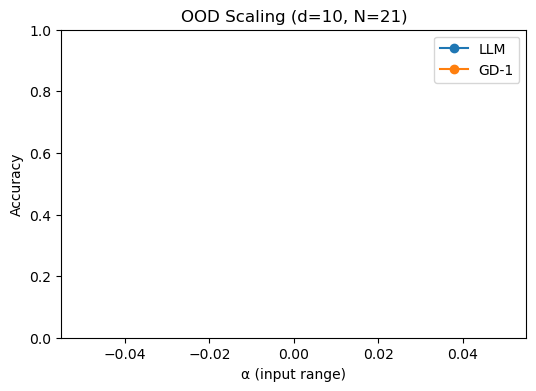

In [48]:
D = int(os.environ.get("D_DIM","10"))
N = 2*D + 1
ETA = 1.0
ALPHAS = [0.5, 1.0, 1.5, 2.0]

print(f"Running backend={BACKEND}, d={D}, N={N}")
results = []
for a in ALPHAS:
    r = eval_clf_suite(n_tasks=10, d=D, N=N, alpha=a, eta=ETA)
    results.append(r)
    print(f"α={a:.1f} → LLM acc={r['acc_llm']:.3f}, GD-1 acc={r['acc_gd1']:.3f}")

plt.figure(figsize=(6,4))
plt.plot(ALPHAS, [r["acc_llm"] for r in results], marker="o", label="LLM")
plt.plot(ALPHAS, [r["acc_gd1"] for r in results], marker="o", label="GD-1")
plt.xlabel("α (input range)")
plt.ylabel("Accuracy")
plt.title(f"OOD Scaling (d={D}, N={N})")
plt.legend(); plt.ylim(0,1); plt.show()